In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]

print("After preprocessing:")
print("Train:", x_train.shape)
print("Test :", x_test.shape)

After preprocessing:
Train: (60000, 28, 28, 1)
Test : (10000, 28, 28, 1)


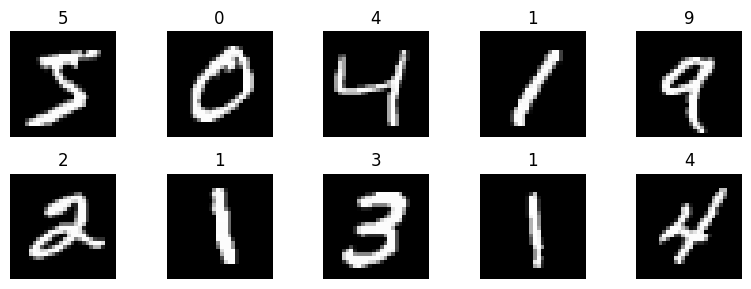

In [ ]:
plt.figure(figsize=(8,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(int(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

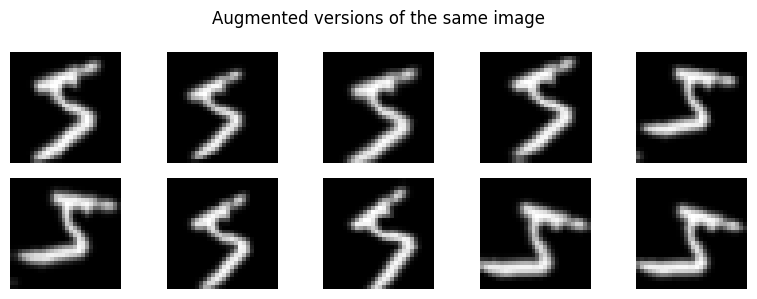

In [ ]:
sample = x_train[0:1]  # one image

plt.figure(figsize=(8,3))
for i in range(10):
    augmented = data_augmentation(sample, training=True)
    plt.subplot(2,5,i+1)
    plt.imshow(augmented[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Augmented versions of the same image")
plt.tight_layout()
plt.show()

In [ ]:
class MinPooling2D(layers.Layer):
    def __init__(self, pool_size=(2,2), strides=None, padding="valid"):
        super(MinPooling2D, self).__init__()
        self.pool = layers.MaxPooling2D(pool_size=pool_size,
                                        strides=strides,
                                        padding=padding)

    def call(self, inputs):
        return -self.pool(-inputs)



def build_cnnmin_with_dropout():
    model_min = models.Sequential([
        layers.Input(shape=(28,28,1)),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation="relu"),
        MinPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation="relu"),
        MinPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.50),
        layers.Dense(10, activation="softmax")
    ], name="CNN_WithMinPooling")
    return model_min
model_min_drop = build_cnnmin_with_dropout()
model_min_drop.summary()

Model: "CNN_WithMinPooling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ min_pooling2d (MinPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ min_pooling2d_1 (MinPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_cnnmin_without_dropout():
    model_min = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation="relu"),
        MinPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation="relu"),
        MinPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ], name="CNN_WithMinPooling_NoDropout")
    return model_min


model_min_no_drop = build_cnnmin_without_dropout()
model_min_no_drop.summary()

Model: "CNN_WithMinPooling_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ min_pooling2d_2 (MinPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ min_pooling2d_3 (MinPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_cnn_baseline():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ], name="CNN_Baseline_NoDropout")
    return model

model_max_no_drop = build_cnn_baseline()
model_max_no_drop.summary()

Model: "CNN_Baseline_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_cnn_with_dropout():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.50),
        layers.Dense(10, activation="softmax")
    ], name="CNN_WithDropout")
    return model

model_max_drop = build_cnn_with_dropout()
model_max_drop.summary()

Model: "CNN_WithDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_min_drop.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_min_no_drop.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_max_drop.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_max_no_drop.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import tensorflow as tf

# Check GPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available:", gpus)

    # Optional: prevent TF from grabbing all GPU memory
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found, using CPU")

No GPU found, using CPU


In [ ]:
# Train all 4 models

EPOCHS = 10
BATCH_SIZE = 128

history_min_drop = model_min_drop.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

history_min_no_drop = model_min_no_drop.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

history_max_drop = model_max_drop.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

history_max_no_drop = model_max_no_drop.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6749 - loss: 0.9936 - val_accuracy: 0.9455 - val_loss: 0.1798
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8412 - loss: 0.5072 - val_accuracy: 0.9644 - val_loss: 0.1112
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8761 - loss: 0.4012 - val_accuracy: 0.9751 - val_loss: 0.0851
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.8925 - loss: 0.3502 - val_accuracy: 0.9761 - val_loss: 0.0775
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9031 - loss: 0.3165 - val_accuracy: 0.9788 - val_loss: 0.0699
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9117 - loss: 0.2871 - val_accuracy: 0.9816 - val_loss: 0.0600
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9169 - loss: 0.2681 - val_accuracy: 0.9815 - val_loss: 0.0593
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9219 - loss: 0.2577 - 

In [ ]:
def print_accuracies(histories, labels):
    print("\n=== Model Accuracy Summary ===\n")

    for history, label in zip(histories, labels):
        train_acc = history.history["accuracy"][-1]
        val_acc = history.history["val_accuracy"][-1]

        print(f"{label}:")
        print(f"  Train Accuracy      : {train_acc:.4f}")
        print(f"  Validation Accuracy : {val_acc:.4f}")
        print("-" * 40)


# Call function
print_accuracies(
    histories=[
        history_min_drop,
        history_min_no_drop,
        history_max_drop,
        history_max_no_drop
    ],
    labels=[
        "Min Dropout",
        "Min No Dropout",
        "Max Dropout",
        "Max No Dropout"
    ]
)


=== Model Accuracy Summary ===

Min Dropout:
  Train Accuracy      : 0.9248
  Validation Accuracy : 0.9833
----------------------------------------
Min No Dropout:
  Train Accuracy      : 0.9732
  Validation Accuracy : 0.9826
----------------------------------------
Max Dropout:
  Train Accuracy      : 0.9622
  Validation Accuracy : 0.9902
----------------------------------------
Max No Dropout:
  Train Accuracy      : 0.9828
  Validation Accuracy : 0.9904
----------------------------------------


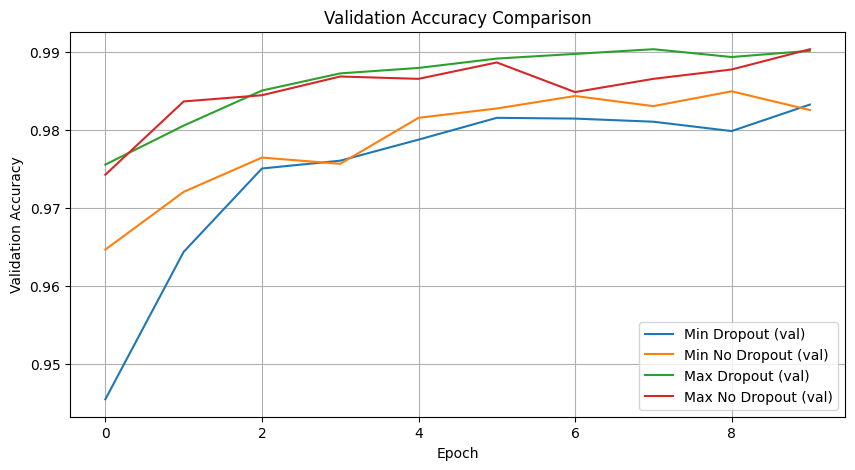

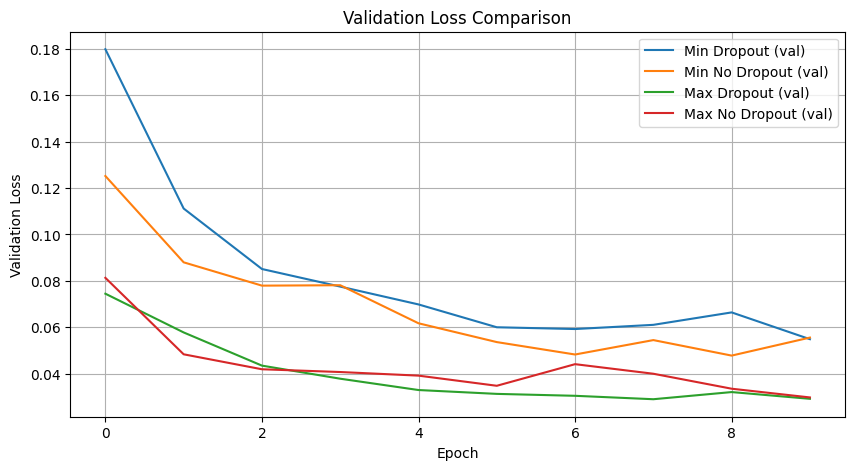

In [ ]:
import matplotlib.pyplot as plt

def plot_all_histories(histories, labels):

    # -------- Accuracy Plot --------
    plt.figure(figsize=(10,5))
    for history, label in zip(histories, labels):
        plt.plot(history.history["val_accuracy"], label=f"{label} (val)")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy Comparison")
    plt.legend()
    plt.grid()
    plt.show()


    # -------- Loss Plot --------
    plt.figure(figsize=(10,5))
    for history, label in zip(histories, labels):
        plt.plot(history.history["val_loss"], label=f"{label} (val)")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()
    plt.grid()
    plt.show()


# Call plotting
plot_all_histories(
    histories=[
        history_min_drop,
        history_min_no_drop,
        history_max_drop,
        history_max_no_drop
    ],
    labels=[
        "Min Dropout",
        "Min No Dropout",
        "Max Dropout",
        "Max No Dropout"
    ]
)

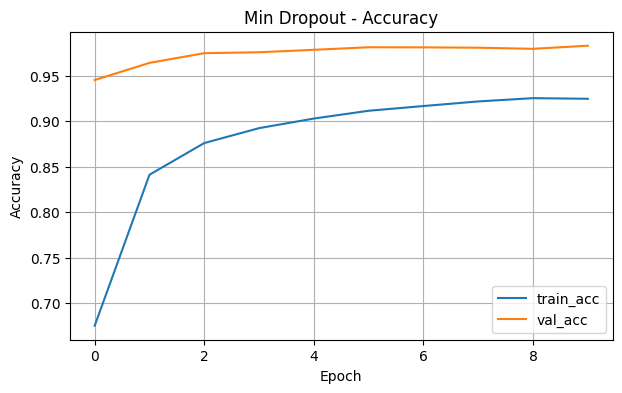

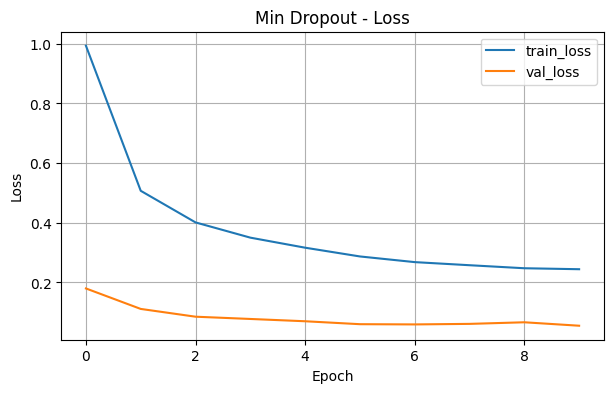

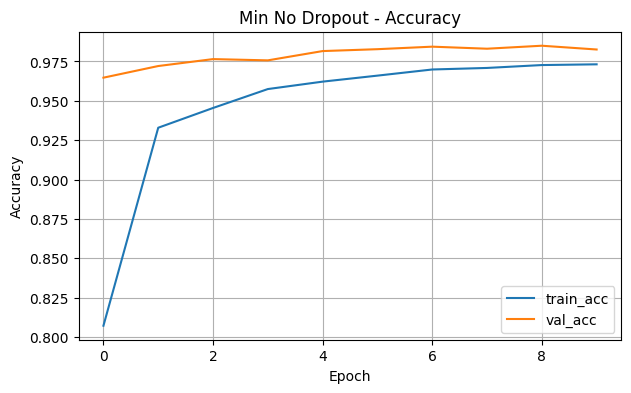

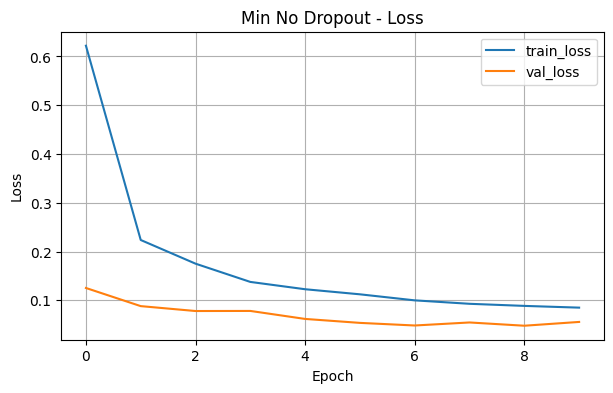

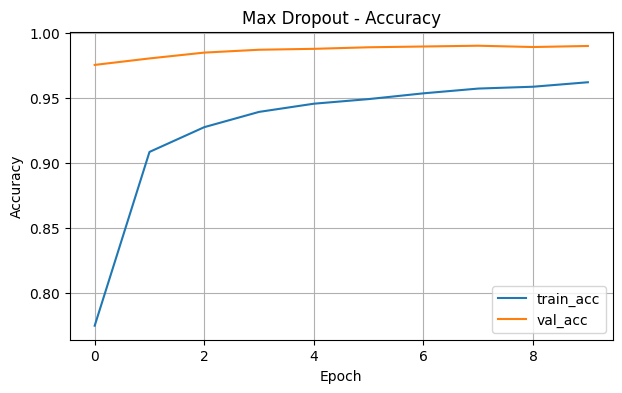

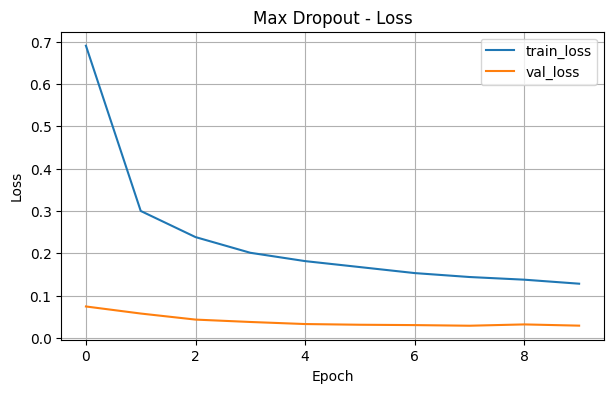

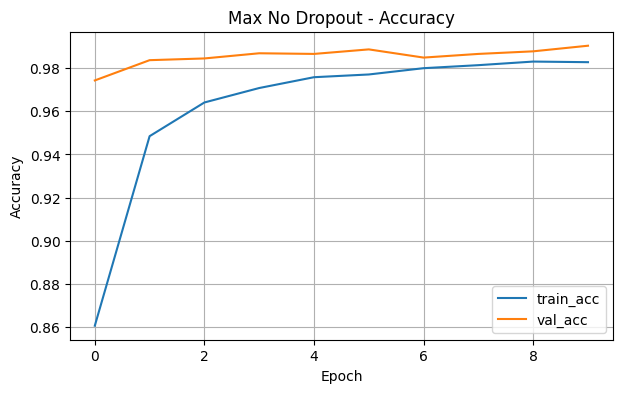

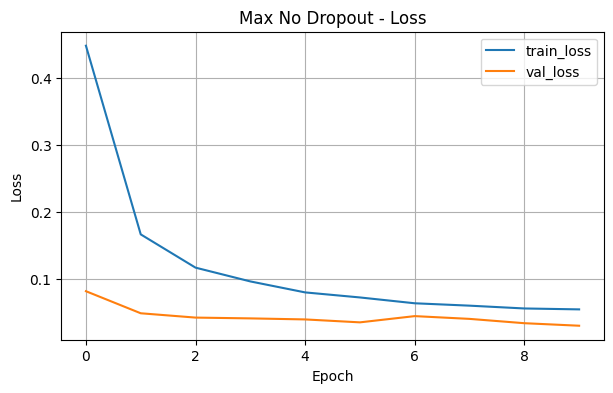

In [ ]:
def plot_single_history(history, title):

    # Accuracy
    plt.figure(figsize=(7,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

    # Loss
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


# Plot individually
plot_single_history(history_min_drop, "Min Dropout")
plot_single_history(history_min_no_drop, "Min No Dropout")
plot_single_history(history_max_drop, "Max Dropout")
plot_single_history(history_max_no_drop, "Max No Dropout")

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 0
